# TCL Pipeline 2 (Refactored and Group-Based)

This notebook follows the same model/loss/evaluation/user-inference style as `TCL_Pipeline_new_1.ipynb`, but replaces day-only temporal construction with grouped temporal pooling.

## 1. Imports

This cell loads all required libraries, sets plotting defaults, and initializes the compute device.

What this prepares:
- numerical/data stack (`numpy`, `pandas`)
- deep learning stack (`torch`)
- progress/visualization utilities

In [1]:
import os
import json
import ast
import warnings
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


/home/hp/SEM2/INLP/Naretve_Shift/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Config

This cell defines all runtime parameters grouped by purpose: paths, topic schema, feature settings, grouping strategy, inference controls, model architecture, training controls, drift thresholds, and reproducibility.

Goal: keep settings easy to audit and change without touching algorithm code.

In [2]:
# -----------------------------
# Config grouped by function
# -----------------------------

# 1) Paths and I/O
path_settings = {
    # Data root folder that contains topic CSV files used for training
    "data_path": "/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/Distributed_Data/BAL_TOPIC_WISE_W3",
    # Output folder for checkpoints, plots, and result artifacts
    "output_path": "./tcl_output_new_2",
}

# 2) Topic and source-data schema
topic_data_settings = {
    # Topic to filename mapping for multi-topic TCL training
    "topic_files": {
        "War": "War.csv",
        "Health": "Health.csv",
        "Economics": "Economics.csv",
        "Technology": "Technology.csv",
        "Climate": "Climate.csv",
    },
    # Canonical topic order used for one-hot/soft topic vectors
    "topics": ["War", "Health", "Economics", "Technology", "Climate"],
    # Embedding column expected in training CSV
    "embedding_column": "w5_embedding",
}

# 3) Feature construction (shared by training + inference)
feature_settings = {
    # SBERT vector size used by the training pipeline contract
    "embedding_dim": 768,
    # Context sentence count for inference embedding construction.
    # If 3 -> [previous, current, next], if 5 -> [prev2, prev1, current, next1, next2].
    "context_window": 5,
    # Minimum sentences needed in one date bucket to keep that day
    "min_sentences_per_day": 3,
    # Sliding window length in groups for temporal context
    "window_size": 2,
    # Sliding stride between windows
    "stride": 1,
}

# 4) Grouping strategy (Pipeline 2 specific)
grouping_settings = {
    # Approach 1: fixed-size grouping by number of days
    "use_fixed_group_size": False,
    "fixed_group_size": 3,
    # Approach 2: grouping by maximum date gap from group start
    "use_max_day_gap": True,
    "max_day_gap": 2,
}

# 5) Inference controls
inference_settings = {
    # Minimum topic score to keep a sentence for selected user topic
    "topic_threshold": 0.27,
    # Batch size for inference-time SBERT encoding (speed/memory tradeoff)
    "inference_batch_size": 32,
}

# 6) Model architecture
model_settings = {
    "hidden_dim": 256,
    "num_heads": 8,
    "num_layers": 3,
    "feed_forward_dim": 512,
    "dropout": 0.1,
    "projection_dim": 128,
}

# 7) Optimization and training
training_settings = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "epochs": 100,
    "weight_decay": 0.01,
    "warmup_epochs": 5,
    "min_lr": 1e-6,
    "temperature": 0.07,
    "gradient_clip": 1.0,
    "use_amp": True,
    "patience": 5,
    "min_delta": 1e-3,
}

# 8) Drift/shift detection
drift_settings = {
    "drift_smoothing_window": 3,
    "zscore_threshold": 1.0,
    "percentile_threshold": 50,
}

# 9) Runtime and reproducibility
runtime_settings = {
    "seed": 42,
}

# 10) Artifact naming and model interface
artifact_settings = {
    "approach_id": "2",
    "model_name_prefix": "approch",
    "model_type": "day_gap" if grouping_settings["use_max_day_gap"] else "fixed_group",
    "model_group_size": (
        grouping_settings["max_day_gap"]
        if grouping_settings["use_max_day_gap"]
        else grouping_settings["fixed_group_size"]
    ),
    "model_name_template": "{model_name_prefix}_{model_type}_{model_group_size}_{approach_id}_w{window_size}_s{stride}_t{temperature_tag}",
    "load_variant": "best",
}

# Flatten grouped blocks into one runtime config (keeps downstream API unchanged).
config = {
    **path_settings,
    **topic_data_settings,
    **feature_settings,
    **grouping_settings,
    **inference_settings,
    **model_settings,
    **training_settings,
    **drift_settings,
    **runtime_settings,
    **artifact_settings,
}


def _temperature_tag(value):
    return str(value).replace(".", "p")


def build_model_base_name(cfg):
    return cfg["model_name_template"].format(
        model_name_prefix=cfg["model_name_prefix"],
        model_type=cfg["model_type"],
        model_group_size=cfg["model_group_size"],
        approach_id=cfg["approach_id"],
        window_size=cfg["window_size"],
        stride=cfg["stride"],
        temperature_tag=_temperature_tag(cfg["temperature"]),
    )


def build_artifact_paths(cfg):
    base_name = build_model_base_name(cfg)
    output_path = cfg["output_path"]
    paths = {
        "model_base_name": base_name,
        "model_best_path": os.path.join(output_path, f"{base_name}_best.pt"),
        "model_last_path": os.path.join(output_path, f"{base_name}_last.pt"),
        "model_evaluated_path": os.path.join(output_path, f"{base_name}_evaluated.pt"),
        "train_loss_plot_path": os.path.join(output_path, f"{base_name}_train_loss.png"),
        "eval_heatmap_intra_path": os.path.join(output_path, f"{base_name}_intra_heatmap.png"),
        "eval_heatmap_inter_path": os.path.join(output_path, f"{base_name}_inter_heatmap.png"),
        "run_summary_path": os.path.join(output_path, f"{base_name}_run_summary.json"),
        "eval_metrics_path": os.path.join(output_path, f"{base_name}_evaluation_metrics.json"),
    }

    variant_to_path = {
        "best": paths["model_best_path"],
        "last": paths["model_last_path"],
        "evaluated": paths["model_evaluated_path"],
    }
    load_variant = str(cfg.get("load_variant", "best")).lower().strip()
    paths["model_load_path"] = variant_to_path.get(load_variant, paths["model_best_path"])
    return paths


def load_checkpoint_compat(path, map_location):
    try:
        return torch.load(path, map_location=map_location)
    except Exception as exc:
        if "Weights only load failed" in str(exc):
            return torch.load(path, map_location=map_location, weights_only=False)
        raise


# Derived dimensions
config["time_dim"] = 1
config["topic_dim"] = len(config["topics"])
config["final_dim"] = config["embedding_dim"] + config["time_dim"] + config["topic_dim"]

if config["context_window"] not in (3, 5):
    raise ValueError("config['context_window'] must be either 3 or 5")

if bool(config["use_fixed_group_size"]) == bool(config["use_max_day_gap"]):
    raise ValueError("Enable exactly one grouping strategy: use_fixed_group_size xor use_max_day_gap")

os.makedirs(config["output_path"], exist_ok=True)
config.update(build_artifact_paths(config))

np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config["seed"])

print("Config ready")
print(
    f"final_dim={config['final_dim']} | topics={len(config['topics'])} | "
    f"window_size={config['window_size']} | context_window={config['context_window']}"
)

if config["use_fixed_group_size"]:
    print(f"Grouping strategy: fixed_group_size={config['fixed_group_size']}")
else:
    print(f"Grouping strategy: max_day_gap={config['max_day_gap']}")

print(f"Model base name: {config['model_base_name']}")
print(f"Default model load path: {config['model_load_path']}")

Config ready
final_dim=774 | topics=5 | window_size=2 | context_window=5
Grouping strategy: max_day_gap=2
Model base name: approch_day_gap_2_2_w2_s1_t0p07
Default model load path: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_best.pt


## 3. Data Loading

This cell parses topic CSV files into a normalized sentence-level structure used by training.

Output columns per row: `date`, `sentence_embeddings`, `topic_embeddings`, `main_sentence`, `sentence_id`.

In [3]:
def parse_embedding(embedding_value):
    if isinstance(embedding_value, np.ndarray):
        return embedding_value.astype(np.float32)
    if isinstance(embedding_value, list):
        return np.asarray(embedding_value, dtype=np.float32)
    if isinstance(embedding_value, str):
        cleaned = embedding_value.strip("[]\"'").replace("\n", " ").replace("\r", " ")
        if "," in cleaned:
            cleaned = cleaned.replace(",", " ")
        sentence_embeddings = np.fromstring(cleaned, sep=" ", dtype=np.float32)
        if sentence_embeddings.size > 0:
            return sentence_embeddings
        parsed = ast.literal_eval(embedding_value)
        return np.asarray(parsed, dtype=np.float32)
    raise ValueError(f"Unsupported embedding value type: {type(embedding_value)}")


def apply_with_optional_progress(series, func, desc=None):
    # Safe wrapper: works with and without tqdm's pandas integration.
    try:
        tqdm.pandas(desc=desc)
        return series.progress_apply(func)
    except Exception:
        return series.apply(func)


def load_topic_dataframe(topic_name, config):
    file_path = os.path.join(config["data_path"], config["topic_files"][topic_name])
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Missing file: {file_path}")

    dataframe = pd.read_csv(file_path)
    dataframe["date"] = pd.to_datetime(dataframe["date"], format="mixed", errors="coerce")
    dataframe = dataframe.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

    embedding_column = config["embedding_column"]
    if embedding_column not in dataframe.columns:
        fallback_column = "w3_embedding" if "w3_embedding" in dataframe.columns else None
        if fallback_column is None:
            raise ValueError(f"No embedding column found in {file_path}")
        embedding_column = fallback_column

    dataframe["sentence_embeddings"] = apply_with_optional_progress(
        dataframe[embedding_column], parse_embedding, desc=f"Parsing {topic_name} embeddings"
    )
    valid_mask = dataframe["sentence_embeddings"].apply(len) == config["embedding_dim"]
    dataframe = dataframe[valid_mask].reset_index(drop=True)

    # Keep training-style topic columns (War/Health/...) for weighting/filtering logic.
    # topic_embeddings stays one-hot by file topic to preserve Approach-1 topic identity encoding.
    topic_cols_present = all(topic in dataframe.columns for topic in config["topics"])
    if topic_cols_present:
        topic_values = dataframe[config["topics"]].astype(np.float32).values
        denom = topic_values.sum(axis=1, keepdims=True)
        denom = np.where(denom > 1e-8, denom, 1.0)
        topic_values = (topic_values / denom).astype(np.float32)
    elif "topic_probabilities" in dataframe.columns:
        parsed_topic_probs = apply_with_optional_progress(
            dataframe["topic_probabilities"], parse_embedding, desc=f"Parsing {topic_name} topic probs"
        )
        topic_values = np.stack(parsed_topic_probs.values).astype(np.float32)
    else:
        topic_index = config["topics"].index(topic_name)
        one_hot = np.eye(len(config["topics"]), dtype=np.float32)[topic_index]
        topic_values = np.repeat(one_hot[None, :], len(dataframe), axis=0).astype(np.float32)

    for topic_idx, topic in enumerate(config["topics"]):
        dataframe[topic] = topic_values[:, topic_idx].astype(np.float32)

    topic_index = config["topics"].index(topic_name)
    one_hot = np.eye(len(config["topics"]), dtype=np.float32)[topic_index]
    dataframe["topic_embeddings"] = [one_hot.copy() for _ in range(len(dataframe))]

    if "main_sentence" not in dataframe.columns:
        dataframe["main_sentence"] = dataframe.get("sentence", "")
    if "sentence_id" not in dataframe.columns:
        dataframe["sentence_id"] = [f"{topic_name}_s{i}" for i in range(len(dataframe))]

    columns = [
        "date", "sentence_embeddings", "topic_embeddings", "main_sentence", "sentence_id"
    ] + config["topics"]
    return dataframe[columns]


topic_sentence_data = {}
for topic_name in config["topics"]:
    topic_sentence_data[topic_name] = load_topic_dataframe(topic_name, config)
    print(f"Loaded {topic_name}: {len(topic_sentence_data[topic_name])} rows")

Parsing War embeddings: 100%|██████████| 34242/34242 [00:09<00:00, 3744.89it/s]


Loaded War: 34242 rows


Parsing Health embeddings: 100%|██████████| 16720/16720 [00:03<00:00, 4194.51it/s]


Loaded Health: 16720 rows


Parsing Economics embeddings: 100%|██████████| 7209/7209 [00:01<00:00, 4355.34it/s]


Loaded Economics: 7209 rows


Parsing Technology embeddings: 100%|██████████| 9281/9281 [00:02<00:00, 4274.36it/s]


Loaded Technology: 9281 rows


Parsing Climate embeddings: 100%|██████████| 14103/14103 [00:03<00:00, 3717.72it/s]


Loaded Climate: 14103 rows


## 4. Preprocessing (Day -> Group)

This cell first creates day-level vectors, then groups consecutive days using one active strategy:

- Approach 1: fixed group size (`use_fixed_group_size=True`)
- Approach 2: max day gap (`use_max_day_gap=True`)

Dimension path stays the same after grouping:
- sentence embedding: `768`
- topic vector: `5`
- time feature: `1`
- final group vector: `774`

In [4]:
def aggregate_daily_vectors(topic_dataframe, topic_name, config):
    temp_df = topic_dataframe.copy()
    temp_df["date_only"] = temp_df["date"].dt.date

    daily_vectors = []
    for date_only, group in temp_df.groupby("date_only"):
        if len(group) < config["min_sentences_per_day"]:
            continue

        sentence_embeddings = np.stack(group["sentence_embeddings"].values).astype(np.float32)

        # Approach-1 compatible weighted pooling priority:
        # 1) topic-specific column (e.g., War/Health/...) when present
        # 2) uniform mean fallback
        if topic_name in group.columns:
            raw_weights = group[topic_name].astype(np.float32).values
        else:
            raw_weights = None

        if raw_weights is not None:
            raw_weights = np.clip(raw_weights, a_min=0.0, a_max=None)
            if raw_weights.sum() > 0:
                weights = raw_weights / raw_weights.sum()
            else:
                weights = np.ones(len(group), dtype=np.float32) / max(len(group), 1)
        else:
            weights = np.ones(len(group), dtype=np.float32) / max(len(group), 1)

        daily_embedding = (sentence_embeddings.T @ weights).astype(np.float32)

        norm = np.linalg.norm(daily_embedding)
        if norm > 1e-8:
            daily_embedding = daily_embedding / norm

        # topic_embeddings may be named either topic_embeddings (normalized internal schema)
        # or topic_probabilities (training-like intermediate schema from inference).
        if "topic_embeddings" in group.columns:
            topic_embeddings = np.asarray(group["topic_embeddings"].iloc[0], dtype=np.float32)
        else:
            topic_index = config["topics"].index(topic_name)
            topic_embeddings = np.eye(len(config["topics"]), dtype=np.float32)[topic_index]

        daily_vectors.append({
            "date": pd.Timestamp(date_only),
            "daily_vectors": daily_embedding,
            "topic_embeddings": topic_embeddings,
            "topic_name": topic_name,
            "topic_id": config["topics"].index(topic_name),
            "num_sentences": int(len(group))
        })

    # Keep schema stable even when no day passes filtering.
    if not daily_vectors:
        return pd.DataFrame(columns=[
            "date", "daily_vectors", "topic_embeddings", "topic_name", "topic_id", "num_sentences"
        ])

    return pd.DataFrame(daily_vectors).sort_values("date").reset_index(drop=True)


def create_groups_fixed_size(daily_dataframe, group_size):
    records = daily_dataframe.sort_values("date").to_dict(orient="records")
    grouped = []

    for i in range(0, len(records), int(group_size)):
        chunk = records[i:i + int(group_size)]
        if not chunk:
            continue

        emb = np.stack([r["daily_vectors"] for r in chunk]).mean(axis=0).astype(np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-8)

        topic_vec = np.stack([r["topic_embeddings"] for r in chunk]).mean(axis=0).astype(np.float32)
        topic_vec = topic_vec / (np.linalg.norm(topic_vec) + 1e-8)

        grouped.append({
            "group_id": len(grouped),
            "date": chunk[0]["date"],
            "end_date": chunk[-1]["date"],
            "daily_vectors": emb,
            "topic_embeddings": topic_vec,
            "topic_name": chunk[0]["topic_name"],
            "topic_id": chunk[0]["topic_id"],
            "num_days": len(chunk),
            "num_sentences": int(sum(int(r.get("num_sentences", 0)) for r in chunk))
        })

    return pd.DataFrame(grouped)


def create_groups_max_day_gap(daily_dataframe, max_day_gap):
    records = daily_dataframe.sort_values("date").to_dict(orient="records")
    if not records:
        return pd.DataFrame(columns=[
            "group_id", "date", "end_date", "daily_vectors", "topic_embeddings",
            "topic_name", "topic_id", "num_days", "num_sentences"
        ])

    grouped_chunks = []
    current = [records[0]]

    for rec in records[1:]:
        gap_days = int((rec["date"] - current[0]["date"]).days)
        if gap_days <= int(max_day_gap):
            current.append(rec)
        else:
            grouped_chunks.append(current)
            current = [rec]

    if current:
        grouped_chunks.append(current)

    grouped = []
    for chunk in grouped_chunks:
        emb = np.stack([r["daily_vectors"] for r in chunk]).mean(axis=0).astype(np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-8)

        topic_vec = np.stack([r["topic_embeddings"] for r in chunk]).mean(axis=0).astype(np.float32)
        topic_vec = topic_vec / (np.linalg.norm(topic_vec) + 1e-8)

        grouped.append({
            "group_id": len(grouped),
            "date": chunk[0]["date"],
            "end_date": chunk[-1]["date"],
            "daily_vectors": emb,
            "topic_embeddings": topic_vec,
            "topic_name": chunk[0]["topic_name"],
            "topic_id": chunk[0]["topic_id"],
            "num_days": len(chunk),
            "num_sentences": int(sum(int(r.get("num_sentences", 0)) for r in chunk))
        })

    return pd.DataFrame(grouped)


def create_grouped_vectors_from_daily(daily_dataframe, topic_name, config):
    if daily_dataframe.empty:
        return pd.DataFrame(columns=[
            "group_id", "date", "end_date", "daily_vectors", "topic_embeddings",
            "topic_name", "topic_id", "num_days", "num_sentences"
        ])

    if config["use_fixed_group_size"]:
        return create_groups_fixed_size(daily_dataframe, config["fixed_group_size"]) 

    if config["use_max_day_gap"]:
        return create_groups_max_day_gap(daily_dataframe, config["max_day_gap"]) 

    raise ValueError("No grouping strategy enabled in config")


def add_temporal_features(group_dataframe):
    records = []
    rows = group_dataframe.sort_values("date").to_dict(orient="records")

    for index, row in enumerate(rows):
        if index == 0:
            tau = 0.0
        else:
            day_gap = (row["date"] - rows[index - 1]["date"]).days
            tau = np.log1p(day_gap) / 5.0

        final_vector = np.concatenate([
            row["daily_vectors"],
            np.array([tau], dtype=np.float32),
            row["topic_embeddings"]
        ]).astype(np.float32)

        records.append({
            "date": row["date"],
            "end_date": row.get("end_date", row["date"]),
            "final_vector": final_vector,
            "topic_name": row["topic_name"],
            "topic_id": row["topic_id"],
            "num_sentences": row["num_sentences"],
            "num_days": row.get("num_days", 1)
        })

    return records

## 5. Embedding

This cell builds temporal windows from daily vectors.

Each window tensor shape is `(window_size, final_dim)`; with defaults this is `(3, 774)`.

In [5]:
def build_window_embeddings(enhanced_records, topic_name, topic_id, config):
    # Ensure temporal consistency before creating windows.
    enhanced_records = sorted(enhanced_records, key=lambda x: x["date"])

    window_embeddings = []
    total_groups = len(enhanced_records)

    for start in range(0, total_groups - config["window_size"] + 1, config["stride"]):
        chunk = enhanced_records[start:start + config["window_size"]]
        window_matrix = np.stack([item["final_vector"] for item in chunk]).astype(np.float32)
        window_embeddings.append({
            "tensor": window_matrix,
            "topic_id": topic_id,
            "topic_name": topic_name,
            "start_date": chunk[0]["date"],
            "end_date": chunk[-1].get("end_date", chunk[-1]["date"]),
            "window_idx": start
        })

    return window_embeddings


topic_daily_data = {}
topic_group_data = {}
topic_window_data = {}
all_window_embeddings = []

for topic_name in config["topics"]:
    daily_dataframe = aggregate_daily_vectors(topic_sentence_data[topic_name], topic_name, config)
    grouped_dataframe = create_grouped_vectors_from_daily(daily_dataframe, topic_name, config)

    topic_daily_data[topic_name] = daily_dataframe
    topic_group_data[topic_name] = grouped_dataframe

    enhanced_records = add_temporal_features(grouped_dataframe)
    topic_id = config["topics"].index(topic_name)
    window_embeddings = build_window_embeddings(enhanced_records, topic_name, topic_id, config)

    topic_window_data[topic_name] = window_embeddings
    all_window_embeddings.extend(window_embeddings)

    print(
        f"{topic_name}: days={len(daily_dataframe)} | groups={len(grouped_dataframe)} | windows={len(window_embeddings)}"
    )

print(f"Total window_embeddings: {len(all_window_embeddings)}")

War: days=1681 | groups=850 | windows=849
Health: days=584 | groups=306 | windows=305
Economics: days=196 | groups=116 | windows=115
Technology: days=172 | groups=112 | windows=111
Climate: days=502 | groups=327 | windows=326
Total window_embeddings: 1706


## 6. Model Definition (VERY CLEAR)

This cell defines dataset sampling, temporal encoder architecture, and contrastive loss.

Core model IO:
- input: `(B, T, 774)`
- output: `(B, 128)` normalized embeddings

In [6]:
class TemporalWindowDataset(Dataset):
    def __init__(self, window_embeddings, topics):
        self.window_embeddings = window_embeddings.copy()
        self.topics = topics
        self.topic_groups = {topic: [] for topic in topics}

        for item in self.window_embeddings:
            self.topic_groups[item["topic_name"]].append(item)

        for topic in self.topic_groups:
            self.topic_groups[topic] = sorted(self.topic_groups[topic], key=lambda x: x["window_idx"])

    def __len__(self):
        return len(self.window_embeddings)

    def __getitem__(self, index):
        item = self.window_embeddings[index]
        return torch.from_numpy(item["tensor"]), item["topic_id"]

    def sample_consecutive_pairs(self, batch_size):
        anchors, positives = [], []
        per_topic = max(1, batch_size // max(len(self.topics), 1))

        for topic_name in self.topics:
            topic_windows = self.topic_groups[topic_name]
            if len(topic_windows) < 2:
                continue

            max_start = len(topic_windows) - 1
            sampled_indices = np.random.randint(0, max_start, size=per_topic)

            for idx in sampled_indices:
                anchor_tensor = torch.from_numpy(topic_windows[idx]["tensor"])
                positive_tensor = torch.from_numpy(topic_windows[idx + 1]["tensor"])
                anchors.append(anchor_tensor)
                positives.append(positive_tensor)

        return torch.stack(anchors), torch.stack(positives)

class TCLTemporalEncoder(nn.Module):
    """
    Purpose: encode a temporal window into one normalized representation for contrastive learning.

    Input:  (batch, window_size, final_dim)
    Layers: input LayerNorm + projection -> TransformerEncoder -> attention pooling -> projection head
    Output: (batch, projection_dim), L2 normalized
    """
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.input_norm = nn.LayerNorm(config["final_dim"])
        self.input_projection = nn.Linear(config["final_dim"], config["hidden_dim"])
        self.dropout = nn.Dropout(config["dropout"])

        self.learned_positional = nn.Parameter(
            torch.randn(1, config["window_size"], config["hidden_dim"]) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config["hidden_dim"],
            nhead=config["num_heads"],
            dim_feedforward=config["feed_forward_dim"],
            dropout=config["dropout"],
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config["num_layers"],
            norm=nn.LayerNorm(config["hidden_dim"])
        )

        self.attention_score = nn.Linear(config["hidden_dim"], 1)
        self.post_mlp = nn.Sequential(
            nn.Linear(config["hidden_dim"], config["hidden_dim"]),
            nn.GELU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(config["hidden_dim"], config["hidden_dim"])
        )

        self.projection_head = nn.Sequential(
            nn.Linear(config["hidden_dim"], config["projection_dim"]),
            nn.LayerNorm(config["projection_dim"]),
            nn.GELU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(config["projection_dim"], config["projection_dim"])
        )

    def forward(self, inputs):
        # inputs: (B, T, D) where D = 768 + 1 + number_of_topics
        hidden = self.input_norm(inputs)
        hidden = self.input_projection(hidden)
        hidden = self.dropout(hidden)

        hidden = hidden + self.learned_positional
        encoded = self.transformer(hidden)

        # attention pooling across the temporal axis T
        weights = F.softmax(self.attention_score(encoded), dim=1)
        pooled = (encoded * weights).sum(dim=1)
        pooled = pooled + self.post_mlp(pooled)

        projected = self.projection_head(pooled)
        return F.normalize(projected, p=2, dim=1)

class EnhancedNTXentLoss(nn.Module):
    def __init__(self, temperature):
        super().__init__()
        self.temperature = temperature

    def forward(self, anchor_embeddings, positive_embeddings):
        batch_size = anchor_embeddings.shape[0]
        pair_embeddings = torch.cat([anchor_embeddings, positive_embeddings], dim=0)
        pair_embeddings = F.normalize(pair_embeddings, p=2, dim=1)

        logits = torch.mm(pair_embeddings, pair_embeddings.t()) / self.temperature
        logits = logits - logits.max(dim=1, keepdim=True)[0].detach()

        labels = torch.arange(2 * batch_size, device=pair_embeddings.device)
        labels = (labels + batch_size) % (2 * batch_size)

        mask = torch.eye(2 * batch_size, dtype=torch.bool, device=pair_embeddings.device)
        logits = logits.masked_fill(mask, -1e4)

        return F.cross_entropy(logits, labels)

train_dataset = TemporalWindowDataset(all_window_embeddings, config["topics"])
train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, drop_last=True)

model = TCLTemporalEncoder(config).to(device)
loss_fn = EnhancedNTXentLoss(config["temperature"])
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"], weight_decay=config["weight_decay"])

print(f"Dataset windows: {len(train_dataset)}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Dataset windows: 1706
Model parameters: 1,963,789


## 7. Training

This cell runs contrastive TCL training with warmup+cosine LR schedule, AMP, gradient clipping, and early stopping.

Output: trained model parameters and training history.

Epoch 001 | loss=1.82782 | lr=4.00e-05
Epoch 002 | loss=1.48494 | lr=6.00e-05
Epoch 003 | loss=1.19721 | lr=8.00e-05
Epoch 004 | loss=0.98410 | lr=1.00e-04
Epoch 005 | loss=0.92102 | lr=1.00e-04
Epoch 006 | loss=0.84660 | lr=1.00e-04
Epoch 007 | loss=0.73068 | lr=9.99e-05
Epoch 008 | loss=0.64513 | lr=9.98e-05
Epoch 009 | loss=0.61450 | lr=9.96e-05
Epoch 010 | loss=0.52126 | lr=9.93e-05
Epoch 011 | loss=0.54506 | lr=9.90e-05
Epoch 012 | loss=0.52151 | lr=9.87e-05
Epoch 013 | loss=0.49667 | lr=9.83e-05
Epoch 014 | loss=0.45870 | lr=9.78e-05
Epoch 015 | loss=0.44466 | lr=9.73e-05
Epoch 016 | loss=0.41969 | lr=9.67e-05
Epoch 017 | loss=0.39748 | lr=9.61e-05
Epoch 018 | loss=0.37507 | lr=9.55e-05
Epoch 019 | loss=0.36875 | lr=9.47e-05
Epoch 020 | loss=0.34802 | lr=9.40e-05
Epoch 021 | loss=0.33991 | lr=9.32e-05
Epoch 022 | loss=0.35093 | lr=9.23e-05
Epoch 023 | loss=0.33627 | lr=9.14e-05
Epoch 024 | loss=0.35252 | lr=9.05e-05
Epoch 025 | loss=0.38874 | lr=8.95e-05
Epoch 026 | loss=0.29311 

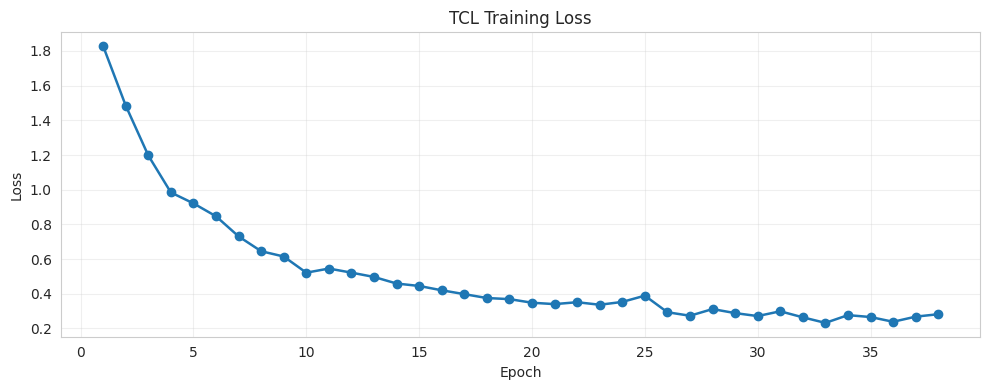

Saved best model: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_best.pt
Saved last model: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_last.pt
Saved train loss plot: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_train_loss.png


In [7]:
def build_scheduler(optimizer, config):
    def lr_lambda(epoch):
        if epoch < config["warmup_epochs"]:
            return float(epoch + 1) / float(config["warmup_epochs"])
        progress = (epoch - config["warmup_epochs"]) / max(1, config["epochs"] - config["warmup_epochs"])
        cosine = 0.5 * (1 + np.cos(np.pi * progress))
        return max(config["min_lr"] / config["learning_rate"], cosine)
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)


def plot_training_loss(history, save_path):
    if not history.get("epoch") or not history.get("loss"):
        return

    plt.figure(figsize=(10, 4))
    plt.plot(history["epoch"], history["loss"], marker="o", linewidth=1.8)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("TCL Training Loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


def train_tcl_model(model, train_dataset, train_loader, optimizer, loss_fn, config, device):
    scheduler = build_scheduler(optimizer, config)
    use_amp = bool(config["use_amp"] and torch.cuda.is_available())
    scaler = torch.cuda.amp.GradScaler() if use_amp else None

    history = {"epoch": [], "loss": [], "lr": [], "best_loss": float("inf"), "best_epoch": 0}
    patience_counter = 0

    for epoch in range(config["epochs"]):
        model.train()
        batch_losses = []

        for _ in train_loader:
            # Forward pass inputs: consecutive temporal windows from same topic
            anchor_windows, positive_windows = train_dataset.sample_consecutive_pairs(config["batch_size"])
            anchor_windows = anchor_windows.to(device)
            positive_windows = positive_windows.to(device)

            optimizer.zero_grad(set_to_none=True)

            # Forward pass
            if use_amp:
                with torch.cuda.amp.autocast():
                    anchor_repr = model(anchor_windows)
                    positive_repr = model(positive_windows)
                    loss = loss_fn(anchor_repr, positive_repr)

                # Backward
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
                scaler.step(optimizer)
                scaler.update()
            else:
                anchor_repr = model(anchor_windows)
                positive_repr = model(positive_windows)
                # Loss computation
                loss = loss_fn(anchor_repr, positive_repr)

                # Backward
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), config["gradient_clip"])
                optimizer.step()

            batch_losses.append(float(loss.item()))

        scheduler.step()
        epoch_loss = float(np.mean(batch_losses)) if batch_losses else float("inf")
        current_lr = optimizer.param_groups[0]["lr"]

        history["epoch"].append(epoch + 1)
        history["loss"].append(epoch_loss)
        history["lr"].append(current_lr)

        improvement = history["best_loss"] - epoch_loss
        if improvement > config["min_delta"]:
            history["best_loss"] = epoch_loss
            history["best_epoch"] = epoch + 1
            patience_counter = 0
            checkpoint = {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "loss": epoch_loss,
                "config": config
            }
            torch.save(checkpoint, config["model_best_path"])
        else:
            patience_counter += 1

        print(f"Epoch {epoch + 1:03d} | loss={epoch_loss:.5f} | lr={current_lr:.2e}")

        if patience_counter >= config["patience"]:
            print("Early stopping triggered")
            break

    # Save last state too, so interface can load best/last/evaluated variants.
    last_checkpoint = {
        "epoch": history["epoch"][-1] if history["epoch"] else 0,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": history["loss"][-1] if history["loss"] else None,
        "config": config
    }
    torch.save(last_checkpoint, config["model_last_path"])

    plot_training_loss(history, config["train_loss_plot_path"])
    print(f"Saved best model: {config['model_best_path']}")
    print(f"Saved last model: {config['model_last_path']}")
    print(f"Saved train loss plot: {config['train_loss_plot_path']}")

    return model, history


model, training_history = train_tcl_model(model, train_dataset, train_loader, optimizer, loss_fn, config, device)

## 8. Evaluation

This cell computes embedding quality diagnostics: intra-topic similarity, inter-topic similarity, and separation score.

Purpose: verify representation quality before inference.

Evaluation Metrics:
{
  "intra_scores": {
    "War": 0.8459478269270317,
    "Health": 0.8749151412566104,
    "Economics": 0.92042213207797,
    "Technology": 0.9117104557427493,
    "Climate": 0.8620943810472537
  },
  "inter_scores": {
    "War-Health": 0.010281910817138851,
    "War-Economics": -0.029727713521569967,
    "War-Technology": -0.07431890838779509,
    "War-Climate": 0.01430447144433856,
    "Health-Economics": 0.021791915162466466,
    "Health-Technology": -0.031488286424428226,
    "Health-Climate": -0.053052423167973754,
    "Economics-Technology": 0.008143995646387339,
    "Economics-Climate": -0.05204669232480228,
    "Technology-Climate": -0.014706050027161837
  },
  "separation_score": -43.971127640037736,
  "similarity_extremes": {
    "intra_min": 0.5929616689682007,
    "intra_max": 0.9980574250221252,
    "inter_min": -0.4945761263370514,
    "inter_max": 0.5152451992034912
  }
}

Similarity Extremes:
Intra -> min: 0.5929616689682007 | max: 0.9980574250221252

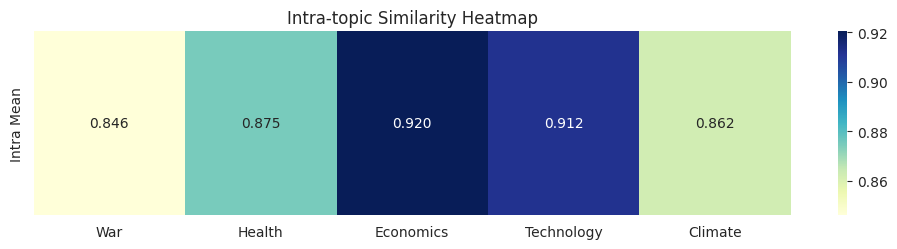

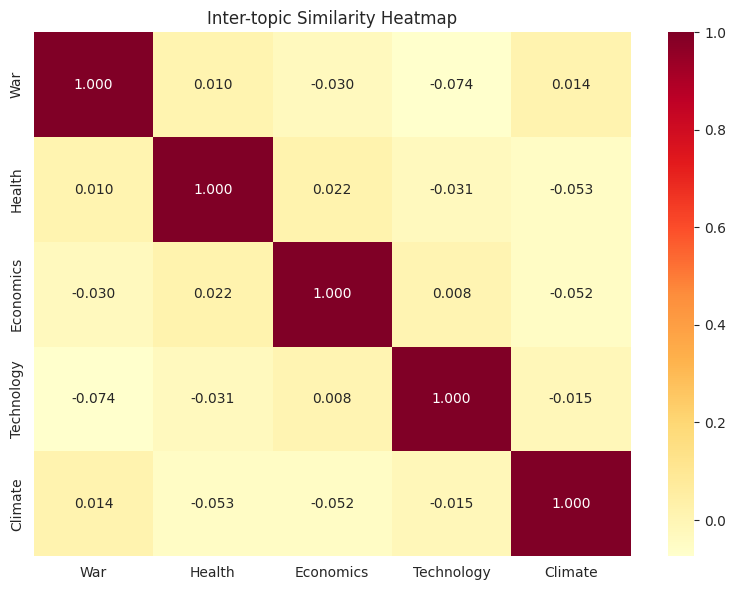

Saved evaluation metrics: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_evaluation_metrics.json
Saved intra heatmap: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_intra_heatmap.png
Saved inter heatmap: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_inter_heatmap.png
Saved evaluated model: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_evaluated.pt


In [8]:
def evaluate_model_quality(model, topic_window_data, config, device, per_topic_limit=200):
    model.eval()
    topic_embeddings = {topic_name: [] for topic_name in config["topics"]}

    with torch.no_grad():
        for topic_name in config["topics"]:
            windows = topic_window_data[topic_name][:per_topic_limit]
            for window in windows:
                tensor = torch.from_numpy(window["tensor"]).unsqueeze(0).to(device)
                encoded = model(tensor).cpu().numpy()[0].astype(np.float32)
                topic_embeddings[topic_name].append(encoded)
            topic_embeddings[topic_name] = np.asarray(topic_embeddings[topic_name], dtype=np.float32)

    intra_scores = {}
    intra_pair_sims = {}
    for topic_name, embeddings in topic_embeddings.items():
        if len(embeddings) < 2:
            continue
        sims = []
        for i in range(len(embeddings) - 1):
            sims.append(float(np.dot(embeddings[i], embeddings[i + 1])))
        intra_pair_sims[topic_name] = sims
        intra_scores[topic_name] = float(np.mean(sims)) if sims else 0.0

    inter_scores = {}
    inter_pair_sims = {}
    topic_names = list(topic_embeddings.keys())
    for i in range(len(topic_names)):
        for j in range(i + 1, len(topic_names)):
            left_name, right_name = topic_names[i], topic_names[j]
            left = topic_embeddings[left_name]
            right = topic_embeddings[right_name]
            if len(left) == 0 or len(right) == 0:
                continue
            pairs = min(100, len(left), len(right))
            sims = []
            for k in range(pairs):
                sims.append(float(np.dot(left[k], right[k])))
            pair_key = f"{left_name}-{right_name}"
            inter_pair_sims[pair_key] = sims
            inter_scores[pair_key] = float(np.mean(sims)) if sims else 0.0

    mean_intra = float(np.mean(list(intra_scores.values()))) if intra_scores else 0.0
    mean_inter = float(np.mean(list(inter_scores.values()))) if inter_scores else 0.0
    separation_score = mean_intra / (mean_inter + 1e-8) if mean_inter != 0 else 0.0

    intra_all = [v for values in intra_pair_sims.values() for v in values]
    inter_all = [v for values in inter_pair_sims.values() for v in values]

    similarity_extremes = {
        "intra_min": float(np.min(intra_all)) if intra_all else None,
        "intra_max": float(np.max(intra_all)) if intra_all else None,
        "inter_min": float(np.min(inter_all)) if inter_all else None,
        "inter_max": float(np.max(inter_all)) if inter_all else None,
    }

    return {
        "intra_scores": intra_scores,
        "inter_scores": inter_scores,
        "separation_score": separation_score,
        "similarity_extremes": similarity_extremes,
    }


def plot_evaluation_heatmaps(evaluation_metrics, config):
    topics = config["topics"]
    intra_scores = evaluation_metrics.get("intra_scores", {})
    inter_scores = evaluation_metrics.get("inter_scores", {})

    intra_values = [float(intra_scores.get(topic, np.nan)) for topic in topics]
    intra_matrix = np.asarray(intra_values, dtype=np.float32).reshape(1, -1)

    inter_matrix = np.full((len(topics), len(topics)), np.nan, dtype=np.float32)
    for i, left in enumerate(topics):
        inter_matrix[i, i] = 1.0
        for j, right in enumerate(topics):
            if i >= j:
                continue
            key = f"{left}-{right}"
            if key not in inter_scores:
                key = f"{right}-{left}"
            if key in inter_scores:
                inter_matrix[i, j] = float(inter_scores[key])
                inter_matrix[j, i] = float(inter_scores[key])

    plt.figure(figsize=(10, 2.6))
    sns.heatmap(
        intra_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        xticklabels=topics,
        yticklabels=["Intra Mean"],
        cbar=True,
    )
    plt.title("Intra-topic Similarity Heatmap")
    plt.tight_layout()
    plt.savefig(config["eval_heatmap_intra_path"], dpi=150)
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        inter_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlOrRd",
        xticklabels=topics,
        yticklabels=topics,
        cbar=True,
    )
    plt.title("Inter-topic Similarity Heatmap")
    plt.tight_layout()
    plt.savefig(config["eval_heatmap_inter_path"], dpi=150)
    plt.show()


evaluation_metrics = evaluate_model_quality(model, topic_window_data, config, device)
print("Evaluation Metrics:")
print(json.dumps(evaluation_metrics, indent=2))

extremes = evaluation_metrics.get("similarity_extremes", {})
print("\nSimilarity Extremes:")
print(
    f"Intra -> min: {extremes.get('intra_min')} | max: {extremes.get('intra_max')} | "
    f"Inter -> min: {extremes.get('inter_min')} | max: {extremes.get('inter_max')}"
)

plot_evaluation_heatmaps(evaluation_metrics, config)

with open(config["eval_metrics_path"], "w", encoding="utf-8") as file:
    json.dump(evaluation_metrics, file, indent=2)

# Store evaluated model immediately after evaluation.
evaluated_checkpoint = {
    "model_state_dict": model.state_dict(),
    "evaluation_metrics": evaluation_metrics,
    "config": config,
}
torch.save(evaluated_checkpoint, config["model_evaluated_path"])

print(f"Saved evaluation metrics: {config['eval_metrics_path']}")
print(f"Saved intra heatmap: {config['eval_heatmap_intra_path']}")
print(f"Saved inter heatmap: {config['eval_heatmap_inter_path']}")
print(f"Saved evaluated model: {config['model_evaluated_path']}")

## 9. Hugging Face Save and Push

> Placement: run this section after model evaluation and before the user inference section.

This block saves run artifacts and uploads model checkpoints, config, metrics, and topic embeddings to Hugging Face for reusable inference.

In [ ]:
# Optional inline auth setup (use this instead of .env loading):
os.environ.setdefault("HF_REPO_ID", "meet5568/tcl-approach")
os.environ.setdefault("HF_TOKEN_READ", "REDACTED_TOKEN")
os.environ.setdefault("HF_TOKEN_PUSH", "REDACTED_TOKEN")

# Hardcoded subfolder for Approach 2. Do not derive this from config or env.
HF_SUBFOLDER_FIXED = "approach_2"

# Example manual setup (uncomment and set real values when needed):
# os.environ["HF_REPO_ID"] = "your_username/your_repo"
# os.environ["HF_TOKEN_READ"] = "your_huggingface_read_token"
# os.environ["HF_TOKEN_PUSH"] = "your_huggingface_push_token"

def save_training_artifacts(config, training_history, evaluation_metrics):
    payload = {
        "config": config,
        "training_history": training_history,
        "evaluation_metrics": evaluation_metrics,
        "artifacts": {
            "model_best_path": config.get("model_best_path"),
            "model_last_path": config.get("model_last_path"),
            "model_evaluated_path": config.get("model_evaluated_path"),
            "train_loss_plot_path": config.get("train_loss_plot_path"),
            "eval_heatmap_intra_path": config.get("eval_heatmap_intra_path"),
            "eval_heatmap_inter_path": config.get("eval_heatmap_inter_path"),
            "eval_metrics_path": config.get("eval_metrics_path"),
        },
    }
    default_name = f"run_summary_new_{config.get('approach_id', '2')}.json"
    save_path = config.get("run_summary_path", os.path.join(config["output_path"], default_name))
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, default=str)
    return save_path


def _build_hf_repo_id(cfg):
    repo_id = str(os.getenv("HF_REPO_ID") or cfg.get("hf_repo_id", "")).strip()
    if repo_id:
        return repo_id
    raise ValueError(
        "Missing HF_REPO_ID. Set it in this cell, e.g. os.environ['HF_REPO_ID'] = 'your_username/your_repo'."
    )


def _resolve_hf_token(mode, required=False):
    """
    mode='read'  -> HF_TOKEN_READ
    mode='push'  -> HF_TOKEN_PUSH
    """
    env_key = "HF_TOKEN_READ" if mode == "read" else "HF_TOKEN_PUSH"
    token = str(os.getenv(env_key) or "").strip()
    if required and not token:
        raise ValueError(
            f"Missing {env_key}. Set it in this cell, e.g. os.environ['{env_key}'] = 'your_huggingface_token'."
        )
    return token or None


def _build_hf_filenames(cfg):
    base_name = cfg["model_base_name"]
    base_hf_name = f"base_approch_{cfg.get('approach_id', '2')}"
    return {
        "best": f"{base_hf_name}_best.pt",
        "last": f"{base_hf_name}_last.pt",
        "evaluated": f"{base_hf_name}_evaluated.pt",
        "run_summary": f"{base_name}_run_summary.json",
        "evaluation_metrics": f"{base_name}_evaluation_metrics.json",
        "config": f"{base_hf_name}_config.json",
        "topic_embeddings": "topic_embeddings.json",
    }


def _upload_if_exists(api, repo_id, local_path, remote_path, commit_message):
    if not local_path or not os.path.exists(local_path):
        print(f"Skip upload (missing): {local_path}")
        return
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=remote_path,
        repo_id=repo_id,
        commit_message=commit_message,
    )
    print(f"Uploaded: {remote_path}")


def push_artifacts_to_huggingface(config, topic_embeddings_json_path=None):
    try:
        from huggingface_hub import HfApi, create_repo
    except ImportError as exc:
        raise ImportError(
            "huggingface_hub is required. Install it with: pip install huggingface_hub"
        ) from exc

    repo_id = _build_hf_repo_id(config)
    token = _resolve_hf_token(mode="push", required=True)
    subfolder = HF_SUBFOLDER_FIXED
    revision = str(config.get("hf_revision", "main"))
    filenames = _build_hf_filenames(config)
    config_to_upload = dict(config)
    print(f"Preparing full config upload with {len(config_to_upload)} keys")

    api = HfApi(token=token)
    create_repo(
        repo_id=repo_id,
        token=token,
        private=bool(config.get("hf_private_repo", False)),
        exist_ok=True,
    )

    export_config_path = os.path.join(config["output_path"], filenames["config"])

    with open(export_config_path, "w", encoding="utf-8") as file:
        json.dump(config_to_upload, file, indent=2, default=str)

    topic_path = topic_embeddings_json_path or config.get("topic_embeddings_source_path")
    commit_message = f"Upload artifacts for {config['model_base_name']}"

    upload_plan = [
        (config.get("model_best_path"), filenames["best"]),
        (config.get("model_last_path"), filenames["last"]),
        (config.get("model_evaluated_path"), filenames["evaluated"]),
        (config.get("run_summary_path"), filenames["run_summary"]),
        (config.get("eval_metrics_path"), filenames["evaluation_metrics"]),
        (export_config_path, filenames["config"]),
        (topic_path, filenames["topic_embeddings"]),
    ]

    for local_path, remote_name in upload_plan:
        remote_path = f"{subfolder}/{remote_name}" if subfolder else remote_name
        _upload_if_exists(
            api=api,
            repo_id=repo_id,
            local_path=local_path,
            remote_path=remote_path,
            commit_message=commit_message,
        )

    return {
        "repo_id": repo_id,
        "revision": revision,
        "subfolder": subfolder,
        "filenames": filenames,
    }


def download_hf_inference_artifacts(config, load_variant=None):
    try:
        from huggingface_hub import hf_hub_download
    except ImportError as exc:
        raise ImportError(
            "huggingface_hub is required. Install it with: pip install huggingface_hub"
        ) from exc

    repo_id = _build_hf_repo_id(config)
    token = _resolve_hf_token(mode="read", required=True)
    revision = str(config.get("hf_revision", "main"))
    subfolder = HF_SUBFOLDER_FIXED
    variant = str(load_variant or config.get("load_variant", "best")).lower().strip()
    filenames = _build_hf_filenames(config)

    if variant not in {"best", "last", "evaluated"}:
        raise ValueError("load_variant must be one of: best, last, evaluated")

    checkpoint_name = f"{subfolder}/{filenames[variant]}" if subfolder else filenames[variant]
    config_name = f"{subfolder}/{filenames['config']}" if subfolder else filenames['config']
    topic_name = f"{subfolder}/{filenames['topic_embeddings']}" if subfolder else filenames['topic_embeddings']

    checkpoint_path = hf_hub_download(
        repo_id=repo_id,
        filename=checkpoint_name,
        revision=revision,
        token=token,
    )
    config_path = hf_hub_download(
        repo_id=repo_id,
        filename=config_name,
        revision=revision,
        token=token,
    )
    topic_embeddings_path = hf_hub_download(
        repo_id=repo_id,
        filename=topic_name,
        revision=revision,
        token=token,
    )

    with open(config_path, "r", encoding="utf-8") as file:
        remote_config = json.load(file)

    return {
        "repo_id": repo_id,
        "revision": revision,
        "subfolder": subfolder,
        "checkpoint_path": checkpoint_path,
        "config_path": config_path,
        "topic_embeddings_path": topic_embeddings_path,
        "remote_config": remote_config,
    }


summary_path = save_training_artifacts(config, training_history, evaluation_metrics)
print(f"Saved summary: {summary_path}")

# Upload training artifacts to Hugging Face so inference can load from Hub.
hf_push_info = push_artifacts_to_huggingface(config)
print(
    f"Uploaded artifacts to Hugging Face: {hf_push_info['repo_id']}"
    f"/{hf_push_info['subfolder']}"
)

Saved summary: ./tcl_output_new_2/approch_day_gap_2_2_w2_s1_t0p07_run_summary.json
Preparing full config upload with 56 keys


Processing Files (1 / 1): 100%|██████████| 23.6MB / 23.6MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


Uploaded: approach_2/base_approch_2_best.pt


Processing Files (1 / 1): 100%|██████████| 23.6MB / 23.6MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


Uploaded: approach_2/base_approch_2_last.pt


Processing Files (1 / 1): 100%|██████████| 7.88MB / 7.88MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  


Uploaded: approach_2/base_approch_2_evaluated.pt
Uploaded: approach_2/approch_day_gap_2_2_w2_s1_t0p07_run_summary.json
Uploaded: approach_2/approch_day_gap_2_2_w2_s1_t0p07_evaluation_metrics.json
Uploaded: approach_2/base_approch_2_config.json
Skip upload (missing): None
Uploaded artifacts to Hugging Face: meet5568/tcl-approach/approach_2


## 9. Inference (User-level)

This section transforms raw user input (`date`, `article`) into training-like sentence rows, applies topic filtering, then reuses the same temporal pipeline used in training.

Result: shift timeline with top contributing sentences.

### Inference Design Notes

- **Context window**: each sentence embedding is generated from contextual text, not isolated text. With `context_window=3`, we use `prev + current + next`; with `context_window=5`, we use `prev2 + prev1 + current + next1 + next2`. This improves semantic quality and reduces noisy single-sentence variance.
- **Soft topic labeling**: every sentence is compared with each topic prototype using cosine similarity. This gives a continuous topic-contribution score instead of hard class labels.
- **Threshold filtering**: only rows where `topic == user_topic` and `similarity_score >= config['topic_threshold']` pass to temporal modeling. This keeps topic-relevant content for stable drift signals.
- **Training-inference alignment**: after filtering, inference uses the same steps as training: daily mean pooling, temporal feature append, sliding windows, encoder forward pass, and consecutive-window drift computation.

In [93]:
def compute_topic_drift(model, topic_windows, config, device):
    model.eval()
    window_embeddings = []

    with torch.no_grad():
        for window in topic_windows:
            tensor = torch.from_numpy(window["tensor"]).unsqueeze(0).to(device)
            encoded = model(tensor).cpu().numpy()[0].astype(np.float32)
            window_embeddings.append(encoded)

    window_embeddings = np.asarray(window_embeddings, dtype=np.float32)
    if len(window_embeddings) < 2:
        return [], window_embeddings

    raw_scores = []
    for i in range(1, len(window_embeddings)):
        raw_scores.append(np.float32(1.0 - float(np.dot(window_embeddings[i], window_embeddings[i - 1]))))

    score_series = pd.Series(raw_scores, dtype=np.float32)
    smooth_scores = score_series.rolling(
        window=config["drift_smoothing_window"], center=True, min_periods=1
    ).mean().astype(np.float32).values

    mean_score = np.float32(np.mean(smooth_scores))
    std_score = np.float32(np.std(smooth_scores)) + np.float32(1e-8)
    z_scores = ((smooth_scores - mean_score) / std_score).astype(np.float32)

    drift_rows = []
    for i, (raw_score, smooth_score, z_score) in enumerate(zip(raw_scores, smooth_scores, z_scores)):
        drift_rows.append({
            "window_idx": int(i + 1),
            "date": topic_windows[i + 1]["start_date"],
            "raw_drift": float(raw_score),
            "drift_score": float(smooth_score),
            "z_score": float(z_score)
        })

    return drift_rows, window_embeddings


def detect_shifts(drift_rows, config):
    if not drift_rows:
        return []
    z_scores = np.asarray([row["z_score"] for row in drift_rows], dtype=np.float32)
    percentile_cutoff = np.percentile(z_scores, config["percentile_threshold"])

    shifts = []
    for row in drift_rows:
        if row["z_score"] > config["zscore_threshold"] or row["z_score"] > percentile_cutoff:
            shifts.append(row)
    return shifts


def split_articles_into_sentences(input_dataframe):
    import re

    sentence_rows = []
    required_cols = {"date", "article"}
    missing = required_cols - set(input_dataframe.columns)
    if missing:
        raise ValueError(f"Input CSV must contain columns: {required_cols}. Missing: {missing}")

    for article_idx, row in input_dataframe.reset_index(drop=True).iterrows():
        article_id = row.get("article_id", f"article_{article_idx}")
        date_value = pd.to_datetime(row["date"], errors="coerce")
        if pd.isna(date_value):
            continue

        text = str(row["article"]).strip()
        if not text:
            continue

        sentence_list = [
            s.strip()
            for s in re.split(r"(?<=[.!?])\s+", text)
            if s and s.strip()
        ]

        for sentence_order, sentence_text in enumerate(sentence_list):
            sentence_id = f"{article_id}_s{sentence_order}"
            sentence_rows.append({
                "date": date_value,
                "article_id": str(article_id),
                "sentence_id": sentence_id,
                "sentence_text": sentence_text,
                "sentence_order": int(sentence_order)
            })

    sentence_dataframe = pd.DataFrame(sentence_rows)
    if sentence_dataframe.empty:
        return pd.DataFrame(columns=["date", "article_id", "sentence_id", "sentence_text", "sentence_order"])
    return sentence_dataframe[["date", "article_id", "sentence_id", "sentence_text", "sentence_order"]]


def build_context_texts(sentence_dataframe, context_window):
    if context_window not in (3, 5):
        raise ValueError("context_window must be 3 or 5")

    radius = context_window // 2
    sentence_dataframe = sentence_dataframe.sort_values(["article_id", "sentence_order"]).reset_index(drop=True).copy()
    context_texts = [""] * len(sentence_dataframe)

    for _, group in sentence_dataframe.groupby("article_id", sort=False):
        indices = group.index.tolist()
        sentences = group["sentence_text"].tolist()

        for local_idx, global_idx in enumerate(indices):
            left = max(0, local_idx - radius)
            right = min(len(sentences), local_idx + radius + 1)
            context_texts[global_idx] = " ".join(sentences[left:right])

    sentence_dataframe["context_text"] = context_texts
    return sentence_dataframe


def generate_contextual_sbert_embeddings(sentence_dataframe, config, sbert_model_name="all-mpnet-base-v2"):
    from sentence_transformers import SentenceTransformer

    if sentence_dataframe.empty:
        sentence_dataframe["sentence_embeddings"] = []
        return sentence_dataframe

    # Inference must stay 768-dim to match training final input dimension contract.
    if int(config["embedding_dim"]) != 768:
        raise ValueError("Inference requires config['embedding_dim'] == 768 to match trained Approach-1 pipeline")

    model_sbert = SentenceTransformer(sbert_model_name)
    encoded = model_sbert.encode(
        sentence_dataframe["context_text"].tolist(),
        batch_size=int(config["inference_batch_size"]),
        show_progress_bar=False,
        convert_to_numpy=True
    )
    encoded = np.asarray(encoded, dtype=np.float32)

    if encoded.shape[1] != config["embedding_dim"]:
        raise ValueError(
            f"SBERT output dim {encoded.shape[1]} does not match config['embedding_dim']={config['embedding_dim']}"
        )

    sentence_dataframe = sentence_dataframe.copy()
    sentence_dataframe["sentence_embeddings"] = [vec.astype(np.float32) for vec in encoded]
    return sentence_dataframe


def load_topic_embedding_prototypes(topic_embeddings_json_path, config):
    with open(topic_embeddings_json_path, "r", encoding="utf-8") as file:
        payload = json.load(file)

    topic_embeddings = {}
    for topic_name in config["topics"]:
        if topic_name not in payload:
            raise KeyError(f"Topic '{topic_name}' missing in {topic_embeddings_json_path}")
        vector = np.asarray(payload[topic_name], dtype=np.float32)
        if vector.shape[0] != config["embedding_dim"]:
            raise ValueError(
                f"Topic embedding dim mismatch for {topic_name}: {vector.shape[0]} vs {config['embedding_dim']}"
            )
        norm = np.linalg.norm(vector)
        topic_embeddings[topic_name] = (vector / (norm + 1e-8)).astype(np.float32)

    return topic_embeddings


def soft_topic_label_sentences(sentence_dataframe, topic_embeddings, config):
    # Returns one row per sentence (training-like), including all topic columns.
    rows = []
    topic_names = config["topics"]
    topic_matrix = np.stack([topic_embeddings[name] for name in topic_names]).astype(np.float32)

    if sentence_dataframe.empty:
        base_cols = [
            "date", "article_id", "sentence_id", "sentence_text", "sentence_order",
            "sentence_embeddings", "topic_embeddings", "topic_probabilities"
        ] + topic_names
        return pd.DataFrame(columns=base_cols)

    for row in sentence_dataframe.itertuples(index=False):
        emb = np.asarray(row.sentence_embeddings, dtype=np.float32)
        emb = emb / (np.linalg.norm(emb) + 1e-8)

        similarities = np.dot(topic_matrix, emb).astype(np.float32)
        exp_sim = np.exp(similarities - np.max(similarities)).astype(np.float32)
        topic_probs = (exp_sim / (exp_sim.sum() + 1e-8)).astype(np.float32)

        record = {
            "date": row.date,
            "article_id": row.article_id,
            "sentence_id": row.sentence_id,
            "sentence_text": row.sentence_text,
            "sentence_order": int(row.sentence_order),
            "sentence_embeddings": emb.astype(np.float32),
            "topic_embeddings": topic_probs.astype(np.float32),
            # Keep both aliases to match training CSV style where w3/w5 may exist.
            "w3_embedding": emb.astype(np.float32),
            "w5_embedding": emb.astype(np.float32),
            "topic_probabilities": topic_probs.astype(np.float32)
        }

        for topic_idx, topic_name in enumerate(topic_names):
            record[topic_name] = np.float32(topic_probs[topic_idx])

        rows.append(record)

    return pd.DataFrame(rows)


def build_topic_score_rows(labeled_sentence_dataframe, config):
    # Long-format explainability table: sentence_id | topic | similarity_score(weight)
    rows = []
    for row in labeled_sentence_dataframe.itertuples(index=False):
        for topic_name in config["topics"]:
            rows.append({
                "sentence_id": row.sentence_id,
                "topic": topic_name,
                "similarity_score": float(getattr(row, topic_name))
            })
    return rows


def filter_user_topic_sentences(labeled_sentence_dataframe, user_topic, config):
    if user_topic not in config["topics"]:
        raise ValueError(f"Unknown topic '{user_topic}'. Expected one of {config['topics']}")

    filtered = labeled_sentence_dataframe[
        labeled_sentence_dataframe[user_topic] >= float(config["topic_threshold"])
    ].copy()
    filtered["selected_topic"] = user_topic
    filtered["similarity_score"] = filtered[user_topic].astype(np.float32)

    return filtered.sort_values(["date", "article_id", "sentence_order"]).reset_index(drop=True)


def validate_inference_alignment(config, filtered_sentence_dataframe):
    required_cols = {"date", "sentence_embeddings", "topic_probabilities", "sentence_text", "sentence_id"}
    missing = required_cols - set(filtered_sentence_dataframe.columns)
    if missing:
        raise ValueError(f"Filtered inference data missing required columns: {missing}")

    emb_dim_ok = filtered_sentence_dataframe["sentence_embeddings"].apply(lambda x: len(x) == config["embedding_dim"]).all()
    topic_dim_ok = filtered_sentence_dataframe["topic_probabilities"].apply(lambda x: len(x) == config["topic_dim"]).all()

    if not emb_dim_ok:
        raise ValueError("Inference sentence embedding dimension mismatch detected")
    if not topic_dim_ok:
        raise ValueError("Inference topic embedding dimension mismatch detected")

    return True


def run_user_level_inference(
    user_csv_path,
    model,
    config,
    topic_name,
    topic_embeddings_json_path,
    sbert_model_name="all-mpnet-base-v2"
):
    # Step 1: Load user article file
    input_dataframe = pd.read_csv(user_csv_path)

    # Step 2-3: Sentence split + sentence dataframe
    sentence_dataframe = split_articles_into_sentences(input_dataframe)
    if sentence_dataframe.empty:
        return {
            "shift_time_series": [],
            "top_topic_sentences": [],
            "topic_score_rows": [],
            "training_like_rows": []
        }

    # Step 4: Context text and contextual SBERT embeddings
    sentence_dataframe = build_context_texts(sentence_dataframe, int(config["context_window"]))
    sentence_dataframe = generate_contextual_sbert_embeddings(
        sentence_dataframe, config, sbert_model_name=sbert_model_name
    )

    # Step 5: Topic embedding loading + soft topic labeling (training-like wide format)
    topic_embeddings = load_topic_embedding_prototypes(topic_embeddings_json_path, config)
    labeled_sentence_dataframe = soft_topic_label_sentences(sentence_dataframe, topic_embeddings, config)
    topic_score_rows = build_topic_score_rows(labeled_sentence_dataframe, config)

    # Step 6: User-selected topic filtering
    filtered_sentence_dataframe = filter_user_topic_sentences(labeled_sentence_dataframe, topic_name, config)
    if filtered_sentence_dataframe.empty:
        return {
            "shift_time_series": [],
            "top_topic_sentences": [],
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    # Explicit cross-check: post-filter inference schema must match main pipeline input contract.
    validate_inference_alignment(config, filtered_sentence_dataframe)

    # Step 7: Convert to same downstream schema used by training preprocessing.
    # Keep topic columns (War/Health/...) to mirror training CSV layout.
    base_cols = [
        "date", "sentence_embeddings", "topic_probabilities", "sentence_text", "sentence_id", "similarity_score"
    ] + config["topics"]
    training_aligned_input = filtered_sentence_dataframe[base_cols].rename(columns={
        "sentence_text": "main_sentence",
        "topic_probabilities": "topic_embeddings",
        "similarity_score": "weight"
    })

    user_daily_df = aggregate_daily_vectors(training_aligned_input, topic_name, config)
    user_records = add_temporal_features(user_daily_df)
    user_windows = build_window_embeddings(
        user_records, topic_name, config["topics"].index(topic_name), config
    )

    drift_rows, _ = compute_topic_drift(model, user_windows, config, device)

    # Step 8: Output with top contributing sentences
    top_sentences_by_date = (
        filtered_sentence_dataframe
        .sort_values(["date", "similarity_score"], ascending=[True, False])
        .groupby("date")["sentence_text"]
        .apply(lambda s: s.head(3).tolist())
        .to_dict()
    )

    shift_time_series = []
    for row in drift_rows:
        date_key = pd.Timestamp(row["date"]).normalize()
        shift_time_series.append({
            "date": str(pd.Timestamp(row["date"]).date()),
            "shift_score": float(row["drift_score"]),
            "top_sentences": top_sentences_by_date.get(date_key, [])
        })

    top_topic_sentences = (
        filtered_sentence_dataframe
        .sort_values("similarity_score", ascending=False)
        .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
        .to_dict(orient="records")
    )

    return {
        "shift_time_series": shift_time_series,
        "top_topic_sentences": top_topic_sentences,
        "topic_score_rows": topic_score_rows,
        # Training-format style intermediate rows (one row per sentence with topic columns).
        "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
    }


def run_user_level_inference_approach1_compatible(
    user_csv_path,
    model,
    config,
    topic_name,
    topic_embeddings_json_path,
    sbert_model_name="all-mpnet-base-v2"
):
    # Alias for explicit naming requested by user: inference compatible with original Approach 1 flow.
    return run_user_level_inference(
        user_csv_path=user_csv_path,
        model=model,
        config=config,
        topic_name=topic_name,
        topic_embeddings_json_path=topic_embeddings_json_path,
        sbert_model_name=sbert_model_name
    )

## 10. Utilities (if needed)

This cell contains helper routines for saving run artifacts (config, training history, evaluation metrics) to JSON.

In [94]:
def save_training_artifacts(config, training_history, evaluation_metrics):
    payload = {
        "config": config,
        "training_history": training_history,
        "evaluation_metrics": evaluation_metrics,
        "artifacts": {
            "model_best_path": config.get("model_best_path"),
            "model_last_path": config.get("model_last_path"),
            "model_evaluated_path": config.get("model_evaluated_path"),
            "train_loss_plot_path": config.get("train_loss_plot_path"),
            "eval_heatmap_intra_path": config.get("eval_heatmap_intra_path"),
            "eval_heatmap_inter_path": config.get("eval_heatmap_inter_path"),
            "eval_metrics_path": config.get("eval_metrics_path"),
        },
    }
    save_path = config.get("run_summary_path", os.path.join(config["output_path"], "run_summary_new_1.json"))
    with open(save_path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, default=str)
    return save_path


summary_path = save_training_artifacts(config, training_history, evaluation_metrics)
print(f"Saved summary: {summary_path}")

Saved summary: ./tcl_output_new_2/approch_fixed_group_2_2_w3_s3_t0p07_run_summary.json


## 11. User Inference Call

Run this cell to execute user-level inference on a CSV file and preview shift outputs.

In [95]:
# CPU-safe override for inference embedding generation
# This redefines the earlier function so SentenceTransformer runs on CPU.
def generate_contextual_sbert_embeddings(sentence_dataframe, config, sbert_model_name="all-mpnet-base-v2"):
    from sentence_transformers import SentenceTransformer

    if sentence_dataframe.empty:
        sentence_dataframe["sentence_embeddings"] = []
        return sentence_dataframe

    if int(config["embedding_dim"]) != 768:
        raise ValueError("Inference requires config['embedding_dim'] == 768 to match trained Approach-1 pipeline")

    model_sbert = SentenceTransformer(sbert_model_name, device="cpu")
    encoded = model_sbert.encode(
        sentence_dataframe["context_text"].tolist(),
        batch_size=int(config["inference_batch_size"]),
        show_progress_bar=False,
        convert_to_numpy=True
    )
    encoded = np.asarray(encoded, dtype=np.float32)

    if encoded.shape[1] != config["embedding_dim"]:
        raise ValueError(
            f"SBERT output dim {encoded.shape[1]} does not match config['embedding_dim']={config['embedding_dim']}"
        )

    sentence_dataframe = sentence_dataframe.copy()
    sentence_dataframe["sentence_embeddings"] = [vec.astype(np.float32) for vec in encoded]
    return sentence_dataframe

In [ ]:
# Enhanced user inference: sentence-level narrative shift is the final goal.
def get_user_inference_call_order():
    return [
        "1. split_articles_into_sentences",
        "2. build_context_texts",
        "3. generate_contextual_sbert_embeddings",
        "4. soft_topic_label_sentences",
        "5. filter_user_topic_sentences",
        "6. aggregate_daily_vectors -> add_temporal_features -> build_window_embeddings",
        "7. compute_topic_drift + detect_shifts (day level trigger)",
        "8. sentence-level shift detection with context (final output)"
    ]


def _normalize_topic_label(text):
    text = str(text).strip().lower()
    return "".join(ch for ch in text if ch.isalnum())


def resolve_topic_name(user_topic, config_topics):
    # Accept aliases such as "war topic" or "health-news" for canonical config topics.
    if user_topic in config_topics:
        return user_topic

    target = _normalize_topic_label(user_topic)
    scored = []
    for topic in config_topics:
        norm_topic = _normalize_topic_label(topic)
        if not norm_topic:
            continue
        if target == norm_topic:
            return topic
        if target in norm_topic or norm_topic in target:
            scored.append((len(norm_topic), topic))

    if scored:
        scored.sort(reverse=True)
        return scored[0][1]

    raise ValueError(
        f"Unsupported topic '{user_topic}'. Choose one of: {config_topics}"
    )


def _to_int_article_id(article_id_value):
    text = str(article_id_value)
    digits = "".join(ch for ch in text if ch.isdigit())
    return int(digits) if digits else -1


def _build_sentence_context_string(row, source_df, context_window=2):
    article_rows = source_df[source_df["article_id"].astype(str) == str(row["article_id"])].copy()
    if article_rows.empty:
        return f">>> [{row['sentence_id']}] {row['sentence_text']}"

    article_rows = article_rows.sort_values("sentence_order").reset_index(drop=True)
    positions = article_rows.index[article_rows["sentence_id"].astype(str) == str(row["sentence_id"])].tolist()
    if not positions:
        return f">>> [{row['sentence_id']}] {row['sentence_text']}"

    pos = positions[0]
    start = max(0, pos - int(context_window))
    end = min(len(article_rows), pos + int(context_window) + 1)
    subset = article_rows.iloc[start:end]

    lines = []
    current_order = int(row["sentence_order"])
    for _, r in subset.iterrows():
        prefix = ">>> " if int(r["sentence_order"]) == current_order else "    "
        lines.append(f"{prefix}[{r['sentence_id']}] {r['sentence_text']}")
    return "\n".join(lines)


def extract_sentence_level_narrative_shifts(
    filtered_sentence_dataframe,
    drift_rows,
    config,
    top_k_shifts=5,
    per_date_sent_limit=40,
    context_window=2
):
    if filtered_sentence_dataframe.empty or not drift_rows:
        return []

    detected_shifts = detect_shifts(drift_rows, config)
    if not detected_shifts:
        return []

    filtered = filtered_sentence_dataframe.copy()
    filtered["date"] = pd.to_datetime(filtered["date"]).dt.normalize()

    unique_dates = sorted(filtered["date"].unique())
    if len(unique_dates) < 2:
        return []

    sentence_level_shifts = []
    ranked_shifts = sorted(detected_shifts, key=lambda x: x.get("z_score", 0.0), reverse=True)[:int(top_k_shifts)]

    for shift in ranked_shifts:
        date_2 = pd.Timestamp(shift["date"]).normalize()
        previous_dates = [d for d in unique_dates if d < date_2]
        if not previous_dates:
            continue

        # Use previous available date so both sentences are from different dates.
        date_1 = previous_dates[-1]

        sents_1 = (
            filtered[filtered["date"] == date_1]
            .sort_values("similarity_score", ascending=False)
            .head(int(per_date_sent_limit))
            .reset_index(drop=True)
        )
        sents_2 = (
            filtered[filtered["date"] == date_2]
            .sort_values("similarity_score", ascending=False)
            .head(int(per_date_sent_limit))
            .reset_index(drop=True)
        )

        if sents_1.empty or sents_2.empty:
            continue

        embs_1 = np.stack(sents_1["sentence_embeddings"].values).astype(np.float32)
        embs_2 = np.stack(sents_2["sentence_embeddings"].values).astype(np.float32)

        norm_1 = embs_1 / (np.linalg.norm(embs_1, axis=1, keepdims=True) + 1e-8)
        norm_2 = embs_2 / (np.linalg.norm(embs_2, axis=1, keepdims=True) + 1e-8)
        sims = np.dot(norm_1, norm_2.T).astype(np.float32)

        min_idx = np.unravel_index(np.argmin(sims), sims.shape)
        min_similarity = float(sims[min_idx])

        sent1 = sents_1.iloc[min_idx[0]]
        sent2 = sents_2.iloc[min_idx[1]]

        sentence_level_shifts.append({
            "date_1": str(pd.Timestamp(date_1).date()),
            "date_2": str(pd.Timestamp(date_2).date()),
            "sentence_id_1": str(sent1["sentence_id"]),
            "article_id_1": _to_int_article_id(sent1["article_id"]),
            "sentence_num_1": int(sent1["sentence_order"]),
            "sentence_1": str(sent1["sentence_text"]),
            "topic_weight_1": float(sent1["similarity_score"]),
            "sentence_id_2": str(sent2["sentence_id"]),
            "article_id_2": _to_int_article_id(sent2["article_id"]),
            "sentence_num_2": int(sent2["sentence_order"]),
            "sentence_2": str(sent2["sentence_text"]),
            "topic_weight_2": float(sent2["similarity_score"]),
            "context_1": _build_sentence_context_string(sent1, filtered, context_window=context_window),
            "context_2": _build_sentence_context_string(sent2, filtered, context_window=context_window),
            "similarity": min_similarity,
            "shift_score": float(1.0 - min_similarity),
            "day_level_shift_score": float(shift.get("drift_score", 0.0)),
            "day_level_z_score": float(shift.get("z_score", 0.0))
        })

    return sentence_level_shifts


# def run_user_level_inference(
#     user_csv_path,
#     model,
#     config,
#     topic_name,
#     topic_embeddings_json_path,
#     sbert_model_name="all-mpnet-base-v2"
# ):
#     call_order = get_user_inference_call_order()
#     resolved_topic = resolve_topic_name(topic_name, config["topics"])

#     input_dataframe = pd.read_csv(user_csv_path)
#     sentence_dataframe = split_articles_into_sentences(input_dataframe)
#     if sentence_dataframe.empty:
#         return {
#             "call_order": call_order,
#             "resolved_topic": resolved_topic,
#             "sentence_level_narrative_shifts": [],
#             "top_topic_sentences": [],
#             "topic_score_rows": [],
#             "training_like_rows": []
#         }

#     sentence_dataframe = build_context_texts(sentence_dataframe, int(config["context_window"]))
#     sentence_dataframe = generate_contextual_sbert_embeddings(
#         sentence_dataframe, config, sbert_model_name=sbert_model_name
#     )

#     topic_embeddings = load_topic_embedding_prototypes(topic_embeddings_json_path, config)
#     labeled_sentence_dataframe = soft_topic_label_sentences(sentence_dataframe, topic_embeddings, config)
#     topic_score_rows = build_topic_score_rows(labeled_sentence_dataframe, config)

#     try:
#         filtered_sentence_dataframe = filter_user_topic_sentences(labeled_sentence_dataframe, resolved_topic, config)
#     except KeyError:
#         # Fallback if helper was edited and raises on topic lookup.
#         if resolved_topic not in labeled_sentence_dataframe.columns:
#             raise
#         threshold = float(config.get("topic_threshold", 0.0))
#         filtered_sentence_dataframe = labeled_sentence_dataframe[
#             labeled_sentence_dataframe[resolved_topic].astype(np.float32) >= threshold
#         ].copy()
#         filtered_sentence_dataframe["selected_topic"] = resolved_topic
#         filtered_sentence_dataframe["similarity_score"] = filtered_sentence_dataframe[resolved_topic].astype(np.float32)

#     if filtered_sentence_dataframe.empty:
#         return {
#             "call_order": call_order,
#             "resolved_topic": resolved_topic,
#             "sentence_level_narrative_shifts": [],
#             "top_topic_sentences": [],
#             "topic_score_rows": topic_score_rows,
#             "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
#         }

#     validate_inference_alignment(config, filtered_sentence_dataframe)

#     base_cols = [
#         "date", "sentence_embeddings", "topic_probabilities", "sentence_text", "sentence_id", "similarity_score"
#     ] + config["topics"]
#     training_aligned_input = filtered_sentence_dataframe[base_cols].rename(columns={
#         "sentence_text": "main_sentence",
#         "topic_probabilities": "topic_embeddings",
#         "similarity_score": "weight"
#     })

#     user_daily_df = aggregate_daily_vectors(training_aligned_input, resolved_topic, config)
#     if user_daily_df.empty:
#         return {
#             "call_order": call_order,
#             "resolved_topic": resolved_topic,
#             "sentence_level_narrative_shifts": [],
#             "top_topic_sentences": [],
#             "topic_score_rows": topic_score_rows,
#             "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
#         }

#     user_records = add_temporal_features(user_daily_df)
#     user_windows = build_window_embeddings(
#         user_records, resolved_topic, config["topics"].index(resolved_topic), config
#     )

#     if len(user_windows) < 2:
#         return {
#             "call_order": call_order,
#             "resolved_topic": resolved_topic,
#             "sentence_level_narrative_shifts": [],
#             "top_topic_sentences": filtered_sentence_dataframe
#                 .sort_values("similarity_score", ascending=False)
#                 .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
#                 .to_dict(orient="records"),
#             "topic_score_rows": topic_score_rows,
#             "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
#         }

#     drift_rows, _ = compute_topic_drift(model, user_windows, config, device)

#     # Final target output: sentence-level narrative shift details.
#     sentence_level_shifts = extract_sentence_level_narrative_shifts(
#         filtered_sentence_dataframe=filtered_sentence_dataframe,
#         drift_rows=drift_rows,
#         config=config,
#         top_k_shifts=5,
#         per_date_sent_limit=40,
#         context_window=2
#     )

#     top_topic_sentences = (
#         filtered_sentence_dataframe
#         .sort_values("similarity_score", ascending=False)
#         .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
#         .to_dict(orient="records")
#     )

#     return {
#         "call_order": call_order,
#         "resolved_topic": resolved_topic,
#         "sentence_level_narrative_shifts": sentence_level_shifts,
#         "top_topic_sentences": top_topic_sentences,
#         "topic_score_rows": topic_score_rows,
#         "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
#     }


# def run_user_level_inference_approach1_compatible(
#     user_csv_path,
#     model,
#     config,
#     topic_name,
#     topic_embeddings_json_path,
#     sbert_model_name="all-mpnet-base-v2"
# ):
#     return run_user_level_inference(
#         user_csv_path=user_csv_path,
#         model=model,
#         config=config,
#         topic_name=topic_name,
#         topic_embeddings_json_path=topic_embeddings_json_path,
#         sbert_model_name=sbert_model_name
#     )

In [97]:
# Pipeline 2 override: keep same inference style, but build temporal windows from grouped vectors.
def run_user_level_inference(
    user_csv_path,
    model,
    config,
    topic_name,
    topic_embeddings_json_path,
    sbert_model_name="all-mpnet-base-v2"
):
    call_order = get_user_inference_call_order()
    resolved_topic = resolve_topic_name(topic_name, config["topics"])

    input_dataframe = pd.read_csv(user_csv_path)
    sentence_dataframe = split_articles_into_sentences(input_dataframe)
    if sentence_dataframe.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": [],
            "training_like_rows": []
        }

    sentence_dataframe = build_context_texts(sentence_dataframe, int(config["context_window"]))
    sentence_dataframe = generate_contextual_sbert_embeddings(
        sentence_dataframe, config, sbert_model_name=sbert_model_name
    )

    topic_embeddings = load_topic_embedding_prototypes(topic_embeddings_json_path, config)
    labeled_sentence_dataframe = soft_topic_label_sentences(sentence_dataframe, topic_embeddings, config)
    topic_score_rows = build_topic_score_rows(labeled_sentence_dataframe, config)

    try:
        filtered_sentence_dataframe = filter_user_topic_sentences(labeled_sentence_dataframe, resolved_topic, config)
    except KeyError:
        if resolved_topic not in labeled_sentence_dataframe.columns:
            raise
        threshold = float(config.get("topic_threshold", 0.0))
        filtered_sentence_dataframe = labeled_sentence_dataframe[
            labeled_sentence_dataframe[resolved_topic].astype(np.float32) >= threshold
        ].copy()
        filtered_sentence_dataframe["selected_topic"] = resolved_topic
        filtered_sentence_dataframe["similarity_score"] = filtered_sentence_dataframe[resolved_topic].astype(np.float32)

    if filtered_sentence_dataframe.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    validate_inference_alignment(config, filtered_sentence_dataframe)

    base_cols = [
        "date", "sentence_embeddings", "topic_probabilities", "sentence_text", "sentence_id", "similarity_score"
    ] + config["topics"]
    training_aligned_input = filtered_sentence_dataframe[base_cols].rename(columns={
        "sentence_text": "main_sentence",
        "topic_probabilities": "topic_embeddings",
        "similarity_score": "weight"
    })

    # User inference uses day-level pooling only (no multi-day grouping),
    # so low-volume user inputs can still pass through temporal modeling.
    user_inference_cfg = dict(config)
    user_inference_cfg["min_sentences_per_day"] = 1
    user_daily_df = aggregate_daily_vectors(training_aligned_input, resolved_topic, user_inference_cfg)

    if user_daily_df.empty:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": [],
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    user_records = add_temporal_features(user_daily_df)
    user_windows = build_window_embeddings(
        user_records, resolved_topic, config["topics"].index(resolved_topic), config
    )

    if len(user_windows) < 2:
        return {
            "call_order": call_order,
            "resolved_topic": resolved_topic,
            "sentence_level_narrative_shifts": [],
            "top_topic_sentences": filtered_sentence_dataframe
                .sort_values("similarity_score", ascending=False)
                .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
                .to_dict(orient="records"),
            "topic_score_rows": topic_score_rows,
            "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
        }

    drift_rows, _ = compute_topic_drift(model, user_windows, config, device)

    sentence_level_shifts = extract_sentence_level_narrative_shifts(
        filtered_sentence_dataframe=filtered_sentence_dataframe,
        drift_rows=drift_rows,
        config=config,
        top_k_shifts=5,
        per_date_sent_limit=40,
        context_window=2
    )

    top_topic_sentences = (
        filtered_sentence_dataframe
        .sort_values("similarity_score", ascending=False)
        .head(20)[["date", "sentence_id", "sentence_text", "similarity_score"]]
        .to_dict(orient="records")
    )

    return {
        "call_order": call_order,
        "resolved_topic": resolved_topic,
        "sentence_level_narrative_shifts": sentence_level_shifts,
        "top_topic_sentences": top_topic_sentences,
        "topic_score_rows": topic_score_rows,
        "training_like_rows": labeled_sentence_dataframe.to_dict(orient="records")
    }


def run_user_level_inference_approach1_compatible(
    user_csv_path,
    model,
    config,
    topic_name,
    topic_embeddings_json_path,
    sbert_model_name="all-mpnet-base-v2"
):
    return run_user_level_inference(
        user_csv_path=user_csv_path,
        model=model,
        config=config,
        topic_name=topic_name,
        topic_embeddings_json_path=topic_embeddings_json_path,
        sbert_model_name=sbert_model_name
    )

In [ ]:
# Batch user inference call (runs all CSV files from an input directory and saves TXT outputs)
from pathlib import Path

# -----------------------------
# User-provided paths
# -----------------------------
input_directory = "/home/hp/SEM2/INLP/Naretve_Shift/Output/Model_Testing/Aprroch_2"
output_directory = "/home/hp/SEM2/INLP/Naretve_Shift/Output/Model_Testing/Aprroch_2/outputs"
topic_embeddings_json_path = "/home/hp/SEM2/INLP/Naretve_Shift/Processed_Data/topic_embeddings.json"

# Enter one or many topics here. Example: ["War", "Health"] or config["topics"] for all.
selected_topics = config["topics"]

# -----------------------------
# Inference interface settings
# -----------------------------
inference_config = dict(config)
inference_config["topic_threshold"] = 0.2
inference_config["zscore_threshold"] = 0.5
inference_config["percentile_threshold"] = 10
inference_config["drift_smoothing_window"] = 1

# Select model variant to load from interface config: best | last | evaluated
inference_config["load_variant"] = "best"
inference_config.update(build_artifact_paths(inference_config))

# Ensure output folder exists
Path(output_directory).mkdir(parents=True, exist_ok=True)

# Fallback order avoids forcing retrain when older checkpoints exist.
legacy_best_path = os.path.join(inference_config["output_path"], "tcl_model_best_new_2.pt")
candidate_paths = [
    inference_config["model_load_path"],
    inference_config.get("model_evaluated_path"),
    legacy_best_path,
]
checkpoint_path = next((p for p in candidate_paths if p and os.path.exists(p)), None)
if checkpoint_path is None:
    raise FileNotFoundError(
        "Checkpoint not found in candidates: " + ", ".join([str(p) for p in candidate_paths if p])
    )

# Force inference to run on CPU
inference_device = torch.device("cpu")
device = inference_device

# Load model once, reuse for all files
inference_model = TCLTemporalEncoder(config).to(inference_device)
checkpoint = load_checkpoint_compat(checkpoint_path, inference_device)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
inference_model.load_state_dict(state_dict)
inference_model.eval()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Normalize user-entered topics and keep valid ones only.
normalized_topics = []
for topic in selected_topics:
    normalized_topics.append(resolve_topic_name(topic, config["topics"]))
normalized_topics = list(dict.fromkeys(normalized_topics))

# Collect all CSV files in input directory
input_dir = Path(input_directory)
if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

csv_files = sorted(input_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {input_dir}")

all_batch_inference_outputs = []

print("Batch inference started")
print(f"Model variant requested: {inference_config['load_variant']}")
print(f"Checkpoint loaded: {checkpoint_path}")
print(f"Input directory: {input_dir}")
print(f"Output directory: {output_directory}")
print(
    f"Config -> approach={config.get('approach_id')} | window_size={inference_config['window_size']} | "
    f"stride={inference_config['stride']} | temperature={inference_config['temperature']}"
)
print(
    f"Thresholds -> topic={inference_config['topic_threshold']} | zscore={inference_config['zscore_threshold']} | "
    f"percentile={inference_config['percentile_threshold']} | smooth_window={inference_config['drift_smoothing_window']}"
)
print(f"Topics to run: {normalized_topics}")
print(f"CSV files detected: {len(csv_files)}")

for file_index, user_csv_file in enumerate(csv_files, 1):
    print("\n" + "=" * 120)
    print(f"FILE {file_index}/{len(csv_files)}: {user_csv_file.name}")
    print("=" * 120)

    inference_results_by_topic = {}

    for selected_topic in normalized_topics:
        print("\n" + "#" * 120)
        print(f"TOPIC: {selected_topic}")
        print("#" * 120)

        result = run_user_level_inference_approach1_compatible(
            user_csv_path=str(user_csv_file),
            model=inference_model,
            config=inference_config,
            topic_name=selected_topic,
            topic_embeddings_json_path=topic_embeddings_json_path,
            sbert_model_name="all-mpnet-base-v2"
        )
        inference_results_by_topic[selected_topic] = result

        print("Function call order:")
        for step in result.get("call_order", []):
            print(f"- {step}")

        shift_count = len(result.get("sentence_level_narrative_shifts", []))
        print(f"Sentence-level narrative shifts: {shift_count}")

    # Keep backward-compatible single-topic variable using first topic result.
    inference_result = inference_results_by_topic[normalized_topics[0]] if normalized_topics else {
        "call_order": [],
        "sentence_level_narrative_shifts": []
    }

    # Save one output TXT per input CSV, using the same base filename.
    output_file_path = Path(output_directory) / f"{user_csv_file.stem}.txt"

    topic_shift_counts = {
        topic_name: len(result.get("sentence_level_narrative_shifts", []))
        for topic_name, result in inference_results_by_topic.items()
    }

    report_lines = []
    report_lines.append("USER INFERENCE FINAL OUTPUT")
    report_lines.append("=" * 100)
    report_lines.append("")
    report_lines.append(f"FILE {file_index}: {os.path.basename(str(user_csv_file))}")
    report_lines.append(f"Input:  {str(user_csv_file)}")
    report_lines.append(f"Output: {str(output_file_path)}")
    report_lines.append("=" * 100)
    report_lines.append("")
    report_lines.append("NARRATIVE SHIFT COUNT BY TOPIC")
    report_lines.append("-" * 100)
    for topic_name in normalized_topics:
        report_lines.append(f"{topic_name}: {topic_shift_counts.get(topic_name, 0)}")

    topic_map = inference_results_by_topic
    report_lines.append("")
    report_lines.append("\n" + "=" * 100)
    report_lines.append(f"FILE {file_index}: {os.path.basename(str(user_csv_file))}")
    report_lines.append(f"Input:  {str(user_csv_file)}")
    report_lines.append(f"Output: {str(output_file_path)}")
    report_lines.append("=" * 100)

    if not topic_map:
        report_lines.append("No topic results found for this file.")
    else:
        report_lines.append(f"Topics in result: {list(topic_map.keys())}")

        for topic_name, result in topic_map.items():
            shifts = result.get("sentence_level_narrative_shifts", [])
            report_lines.append("\n" + "#" * 100)
            report_lines.append(f"TOPIC: {topic_name} | Total sentence-level shifts: {len(shifts)}")
            report_lines.append("#" * 100)

            if not shifts:
                report_lines.append("No sentence-level shifts detected. Try lowering topic/zscore thresholds.")
                continue

            for i, shift in enumerate(shifts, 1):
                date_1 = shift.get("date_1")
                date_2 = shift.get("date_2")
                similarity = float(shift.get("similarity", 0.0))
                shift_score = float(shift.get("shift_score", 0.0))
                day_z = float(shift.get("day_level_z_score", 0.0))

                sentence_id_1 = shift.get("sentence_id_1")
                article_id_1 = shift.get("article_id_1")
                sentence_num_1 = shift.get("sentence_num_1")
                topic_weight_1 = float(shift.get("topic_weight_1", 0.0))
                context_1 = shift.get("context_1", "")

                sentence_id_2 = shift.get("sentence_id_2")
                article_id_2 = shift.get("article_id_2")
                sentence_num_2 = shift.get("sentence_num_2")
                topic_weight_2 = float(shift.get("topic_weight_2", 0.0))
                context_2 = shift.get("context_2", "")

                report_lines.append(f"\nShift #{i}: {date_1} -> {date_2}")
                report_lines.append(f"similarity={similarity:.4f} | shift_score={shift_score:.4f} | day_z={day_z:.4f}")
                report_lines.append(f"\nDay 1 - {sentence_id_1} (Article {article_id_1}, Sentence {sentence_num_1})")
                report_lines.append(f"topic_weight={topic_weight_1:.3f}")
                report_lines.append(context_1)
                report_lines.append(f"\nDay 2 - {sentence_id_2} (Article {article_id_2}, Sentence {sentence_num_2})")
                report_lines.append(f"topic_weight={topic_weight_2:.3f}")
                report_lines.append(context_2)
                report_lines.append("-" * 100)

    with open(output_file_path, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines) + "\n")

    all_batch_inference_outputs.append({
        "input_file": str(user_csv_file),
        "output_file": str(output_file_path),
        "results_by_topic": inference_results_by_topic,
        "topic_shift_counts": topic_shift_counts,
    })

    print("Saved output TXT file:")
    print(output_file_path)

print("\nBatch inference completed.")
print(f"Total processed files: {len(all_batch_inference_outputs)}")

Inference completed on CPU using stored checkpoint
Model variant requested: best
Checkpoint loaded: ./tcl_output_new_2/approch_fixed_group_2_2_w3_s3_t0p07_best.pt
Config -> approach=2 | window_size=3 | stride=3 | temperature=0.07
Thresholds -> topic=0.2 | zscore=0.5 | percentile=10 | smooth_window=1
Topics to run: ['War', 'Health', 'Economics', 'Technology', 'Climate']

########################################################################################################################
TOPIC: War
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 408.44it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. soft_topic_label_sentences
- 5. filter_user_topic_sentences
- 6. aggregate_daily_vectors -> add_temporal_features -> build_window_embeddings
- 7. compute_topic_drift + detect_shifts (day level trigger)
- 8. sentence-level shift detection with context (final output)
Sentence-level narrative shifts: 0
SENTENCE-LEVEL NARRATIVE SHIFTS (FINAL OUTPUT)

########################################################################################################################
TOPIC: Health
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 481.25it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. soft_topic_label_sentences
- 5. filter_user_topic_sentences
- 6. aggregate_daily_vectors -> add_temporal_features -> build_window_embeddings
- 7. compute_topic_drift + detect_shifts (day level trigger)
- 8. sentence-level shift detection with context (final output)
Sentence-level narrative shifts: 0
SENTENCE-LEVEL NARRATIVE SHIFTS (FINAL OUTPUT)

########################################################################################################################
TOPIC: Economics
########################################################################################################################


...

Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. soft_topic_label_sentences
- 5. filter_user_topic_sentences
- 6. aggregate_daily_vectors -> add_temporal_features -> build_window_embeddings
- 7. compute_topic_drift + detect_shifts (day level trigger)
- 8. sentence-level shift detection with context (final output)
Sentence-level narrative shifts: 0
SENTENCE-LEVEL NARRATIVE SHIFTS (FINAL OUTPUT)

########################################################################################################################
TOPIC: Technology
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 384.00it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. soft_topic_label_sentences
- 5. filter_user_topic_sentences
- 6. aggregate_daily_vectors -> add_temporal_features -> build_window_embeddings
- 7. compute_topic_drift + detect_shifts (day level trigger)
- 8. sentence-level shift detection with context (final output)
Sentence-level narrative shifts: 0
SENTENCE-LEVEL NARRATIVE SHIFTS (FINAL OUTPUT)

########################################################################################################################
TOPIC: Climate
########################################################################################################################


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 521.90it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Function call order:
- 1. split_articles_into_sentences
- 2. build_context_texts
- 3. generate_contextual_sbert_embeddings
- 4. soft_topic_label_sentences
- 5. filter_user_topic_sentences
- 6. aggregate_daily_vectors -> add_temporal_features -> build_window_embeddings
- 7. compute_topic_drift + detect_shifts (day level trigger)
- 8. sentence-level shift detection with context (final output)
Sentence-level narrative shifts: 0
SENTENCE-LEVEL NARRATIVE SHIFTS (FINAL OUTPUT)

Saved multi-topic inference output:
./tcl_output_new_2/approch_fixed_group_2_2_w3_s3_t0p07_user_inference_multi_topic.json


## 12. User Inference Sentence-Level Output (Final)

This stage is user-inference only. It prints final sentence-level narrative shift pairs with context and does not run training-side sentence-level detection.

In [ ]:
# User-inference final print block (batch-friendly)
print("USER INFERENCE FINAL OUTPUT")
print("=" * 100)

if "all_batch_inference_outputs" in globals() and all_batch_inference_outputs:
    print(f"Total files in batch result: {len(all_batch_inference_outputs)}")

    for file_idx, file_result in enumerate(all_batch_inference_outputs, 1):
        input_file = file_result.get("input_file", "")
        output_file = file_result.get("output_file", "")
        topic_map = file_result.get("results_by_topic", {})

        print("\n" + "=" * 100)
        print(f"FILE {file_idx}: {os.path.basename(str(input_file))}")
        print(f"Input:  {input_file}")
        print(f"Output: {output_file}")
        print("=" * 100)

        if not topic_map:
            print("No topic results found for this file.")
            continue

        print(f"Topics in result: {list(topic_map.keys())}")

        for topic_name, result in topic_map.items():
            shifts = result.get("sentence_level_narrative_shifts", [])
            print("\n" + "#" * 100)
            print(f"TOPIC: {topic_name} | Total sentence-level shifts: {len(shifts)}")
            print("#" * 100)

            if not shifts:
                print("No sentence-level shifts detected. Try lowering topic/zscore thresholds.")
                continue

            for i, shift in enumerate(shifts, 1):
                date_1 = shift.get("date_1")
                date_2 = shift.get("date_2")
                similarity = float(shift.get("similarity", 0.0))
                shift_score = float(shift.get("shift_score", 0.0))
                day_z = float(shift.get("day_level_z_score", 0.0))

                sentence_id_1 = shift.get("sentence_id_1")
                article_id_1 = shift.get("article_id_1")
                sentence_num_1 = shift.get("sentence_num_1")
                topic_weight_1 = float(shift.get("topic_weight_1", 0.0))
                context_1 = shift.get("context_1", "")

                sentence_id_2 = shift.get("sentence_id_2")
                article_id_2 = shift.get("article_id_2")
                sentence_num_2 = shift.get("sentence_num_2")
                topic_weight_2 = float(shift.get("topic_weight_2", 0.0))
                context_2 = shift.get("context_2", "")

                print(f"\nShift #{i}: {date_1} -> {date_2}")
                print(f"similarity={similarity:.4f} | shift_score={shift_score:.4f} | day_z={day_z:.4f}")
                print(f"\nDay 1 - {sentence_id_1} (Article {article_id_1}, Sentence {sentence_num_1})")
                print(f"topic_weight={topic_weight_1:.3f}")
                print(context_1)
                print(f"\nDay 2 - {sentence_id_2} (Article {article_id_2}, Sentence {sentence_num_2})")
                print(f"topic_weight={topic_weight_2:.3f}")
                print(context_2)
                print("-" * 100)
else:
    print("Run the batch user inference call cell first.")

USER INFERENCE FINAL OUTPUT
Topics in result: ['War', 'Health', 'Economics', 'Technology', 'Climate']

####################################################################################################
TOPIC: War | Total sentence-level shifts: 0
####################################################################################################
No sentence-level shifts detected. Try lowering topic/zscore thresholds.

####################################################################################################
TOPIC: Health | Total sentence-level shifts: 0
####################################################################################################
No sentence-level shifts detected. Try lowering topic/zscore thresholds.

####################################################################################################
TOPIC: Economics | Total sentence-level shifts: 0
####################################################################################################
No